# 🕸️ Interaction Network Analysis (NetworkX) + VADER sentiment

Who talks / trades with whom in the water-scarcity simulation — visualized as a graph,
with **nodes colored by their average VADER sentiment**.

The simulation gives us two natural directed networks (from `decisions_*.csv`):

| Network | Built from | Edge meaning |
|---------|-----------|--------------|
| 🤝 **Trade / cooperation** | `move_type == "propose_trade"` (`stakeholder_id → trade_target`) | "I propose a water trade to you" |
| 💥 **Cascade / harm**       | `move_type == "cascade_effect"` (`stakeholder_id → trade_target`) | "my shortfall cascades onto you" |

**Node color** = mean `compound` sentiment of that stakeholder's statements
(green = positive, red = negative). **Node size** = how active the stakeholder is.


In [1]:
# --- Install deps if missing ---
import importlib, sys, subprocess
for pkg, mod in [("networkx","networkx"), ("vaderSentiment","vaderSentiment")]:
    try: importlib.import_module(mod)
    except ModuleNotFoundError: subprocess.check_call([sys.executable,"-m","pip","install",pkg])

import glob
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

plt.rcParams.update({"figure.dpi":110, "font.size":11,
                     "axes.spines.top":False, "axes.spines.right":False})
analyzer = SentimentIntensityAnalyzer()

# diverging colormap for sentiment
SENT_CMAP = plt.get_cmap("RdYlGn")
print("libs ready | networkx", nx.__version__)

libs ready | networkx 3.5


In [2]:
# --- Load latest CSVs (works whether the notebook sits in ./ or a subfolder) ---
def latest(prefix):
    files = sorted(glob.glob(f"{prefix}_*.csv") + glob.glob(f"../{prefix}_*.csv"))
    if not files: raise FileNotFoundError(f"{prefix}_*.csv not found in . or ..")
    return files[-1]

decisions = pd.read_csv(latest("decisions"))
print("decisions:", decisions.shape, "| conditions:", list(decisions['condition'].unique()))

# Short display labels
LABELS = {
    "hospital":"Hospital", "households":"Households", "agriculture":"Agriculture",
    "industry":"Industry", "energy_utility":"Energy", "epa":"EPA",
    "water_authority":"Water Auth.",
}
decisions.head(2)

decisions: (3195, 13) | conditions: ['no_cascade', 'cascade', 'deeper_cascade']


,day,stakeholder_id,name,event_type,round,move_type,units,trade_target,text,run_id,condition,seed,reasoning
0,1,hospital,Hospital / Healthcare Services,request,0,request,150.0,NaN,Our hospitals and clinics cannot safely reduce...,no_cascade_seed0,no_cascade,0,NaN
1,1,households,Households,request,0,request,400.0,NaN,Households need the full baseline today to pre...,no_cascade_seed0,no_cascade,0,NaN


In [3]:
# --- Per-stakeholder average VADER sentiment (for node color) ---
decisions["compound"] = decisions["text"].astype(str).apply(
    lambda t: analyzer.polarity_scores(t)["compound"])

node_sent = decisions.groupby("stakeholder_id")["compound"].mean().to_dict()
node_act  = decisions.groupby("stakeholder_id").size().to_dict()   # activity = #statements

sent_df = (pd.Series(node_sent).rename("mean_compound")
           .sort_values().to_frame())
sent_df["statements"] = pd.Series(node_act)
print("Average sentiment per stakeholder:")
sent_df.round(3)

Average sentiment per stakeholder:


,mean_compound,statements
industry,-0.361,522
agriculture,-0.337,489
epa,-0.212,468
water_authority,-0.186,324
energy_utility,-0.065,471
households,0.052,453
hospital,0.110,468


In [4]:
# --- Build directed edge lists, aggregating parallel edges ---
def edge_list(df, move):
    e = df[(df["move_type"]==move) & (df["trade_target"].notna())]
    g = (e.groupby(["stakeholder_id","trade_target"])
           .agg(count=("units","size"), volume=("units", lambda u: u.abs().sum()))
           .reset_index())
    return g

trade_edges   = edge_list(decisions, "propose_trade")
cascade_edges = edge_list(decisions, "cascade_effect")
print("trade edges:  ", len(trade_edges), "| total proposals:", int(trade_edges['count'].sum()))
print("cascade edges:", len(cascade_edges), "| total effects: ", int(cascade_edges['count'].sum()))
trade_edges.head()

trade edges:   13 | total proposals: 102
cascade edges: 7 | total effects:  81


,stakeholder_id,trade_target,count,volume
0,agriculture,households,12,218.0
1,agriculture,water_authority,6,206.0
2,energy_utility,agriculture,2,24.0
3,energy_utility,hospital,9,112.0
4,energy_utility,households,24,320.0


In [5]:
# --- Helper: build a DiGraph and draw it with sentiment-colored nodes ---
ALL_NODES = list(LABELS.keys())

def build_graph(edges_df):
    G = nx.DiGraph()
    G.add_nodes_from(ALL_NODES)
    for _, r in edges_df.iterrows():
        G.add_edge(r["stakeholder_id"], r["trade_target"],
                   count=r["count"], volume=r["volume"])
    return G

# one shared layout so every figure keeps nodes in the same place
_Gfull = build_graph(pd.concat([trade_edges, cascade_edges]))
POS = nx.spring_layout(_Gfull, seed=42, k=1.1)

VMAX = max(abs(v) for v in node_sent.values())

def draw_network(G, ax, title, edge_color, curved=True):
    active = [n for n in G.nodes if G.degree(n) > 0]
    ncolor = [SENT_CMAP((node_sent.get(n,0)+VMAX)/(2*VMAX)) for n in active]
    nsize  = [300 + 60*node_act.get(n,0)**0.6 for n in active]

    # edges
    widths = [0.6 + 2.2*G[u][v]["count"]/max(1, max(d["count"] for *_,d in G.edges(data=True)))
              for u,v in G.edges()]
    nx.draw_networkx_edges(G, POS, ax=ax, edge_color=edge_color, width=widths,
                           alpha=0.6, arrowsize=14, arrowstyle="-|>",
                           connectionstyle="arc3,rad=0.12" if curved else "arc3,rad=0",
                           node_size=[nsize[active.index(n)] if n in active else 300 for n in G.nodes])
    nx.draw_networkx_nodes(G, POS, nodelist=active, ax=ax,
                           node_color=ncolor, node_size=nsize,
                           edgecolors="#333", linewidths=1.2)
    nx.draw_networkx_labels(G, POS, labels={n:LABELS[n] for n in active}, ax=ax,
                            font_size=9, font_weight="bold")
    # edge weight labels (counts)
    elabels = {(u,v): int(G[u][v]["count"]) for u,v in G.edges()}
    nx.draw_networkx_edge_labels(G, POS, edge_labels=elabels, ax=ax, font_size=8,
                                 label_pos=0.4, bbox=dict(boxstyle="round,pad=0.1",
                                 fc="white", ec="none", alpha=0.7))
    ax.set_title(title, weight="bold"); ax.axis("off")

print("helpers ready")

helpers ready


## 1. 🤝 Trade / cooperation network
Arrow **A → B** = A proposed a water trade to B. Number on edge = how many proposals.

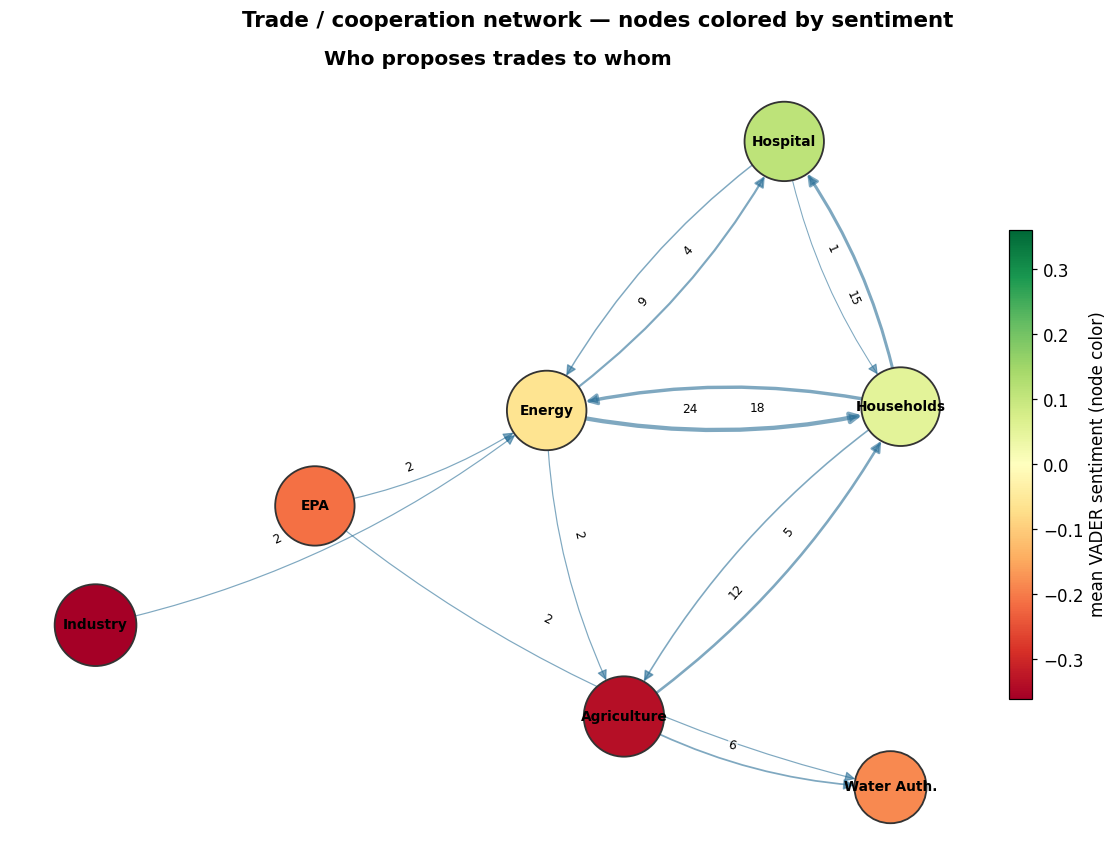

In [6]:
fig, ax = plt.subplots(figsize=(11, 8))
G_trade = build_graph(trade_edges)
draw_network(G_trade, ax, "Who proposes trades to whom", edge_color="#2a6f97")

sm = cm.ScalarMappable(cmap=SENT_CMAP, norm=colors.Normalize(-VMAX, VMAX))
cb = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cb.set_label("mean VADER sentiment (node color)")
fig.suptitle("Trade / cooperation network — nodes colored by sentiment",
             fontsize=14, weight="bold")
plt.tight_layout(); plt.show()

## 2. 💥 Cascade / harm network
Arrow **A → B** = A's shortfall cascades onto B. Red edges = propagation of harm.

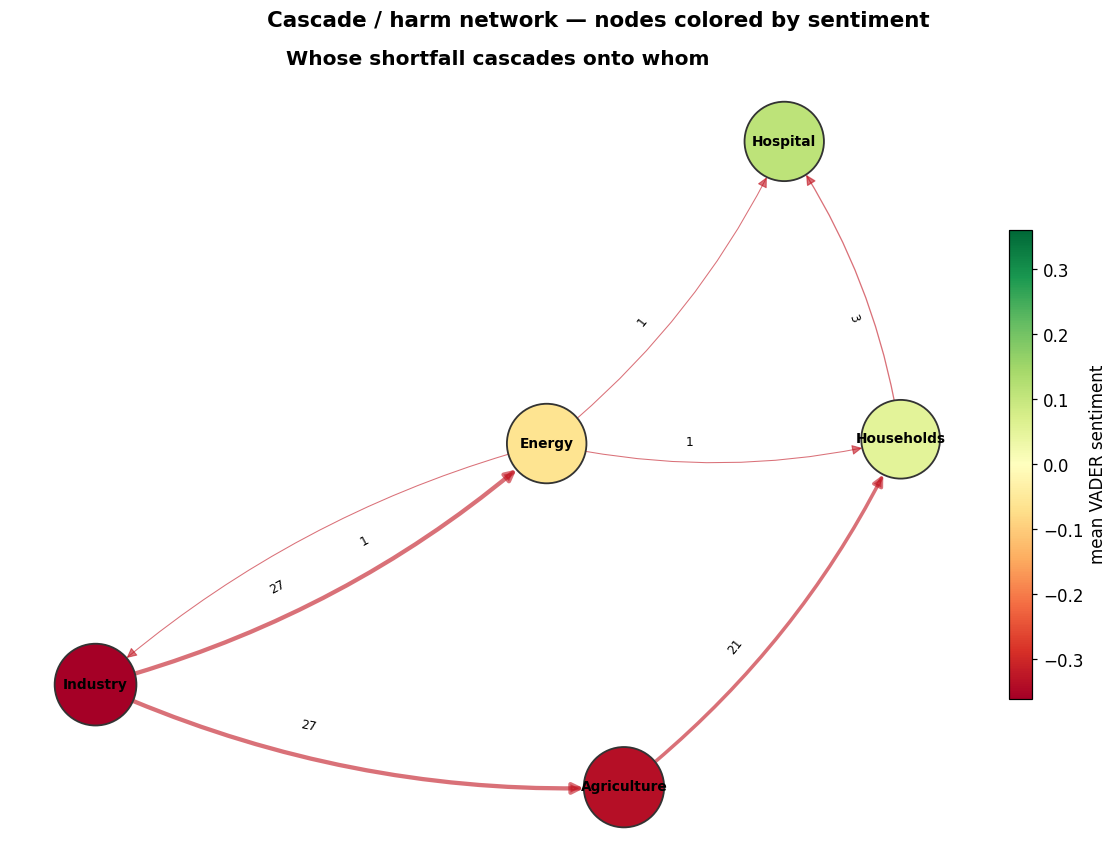

In [7]:
fig, ax = plt.subplots(figsize=(11, 8))
G_casc = build_graph(cascade_edges)
draw_network(G_casc, ax, "Whose shortfall cascades onto whom", edge_color="#c1121f")

sm = cm.ScalarMappable(cmap=SENT_CMAP, norm=colors.Normalize(-VMAX, VMAX))
cb = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02); cb.set_label("mean VADER sentiment")
fig.suptitle("Cascade / harm network — nodes colored by sentiment",
             fontsize=14, weight="bold")
plt.tight_layout(); plt.show()

## 3. 🎯 Centrality — who is the key broker?
Which stakeholders sit at the center of the trade network.
- **Degree** = total number of trade links.
- **Betweenness** = how often a node lies on the shortest path between others (a "bridge").

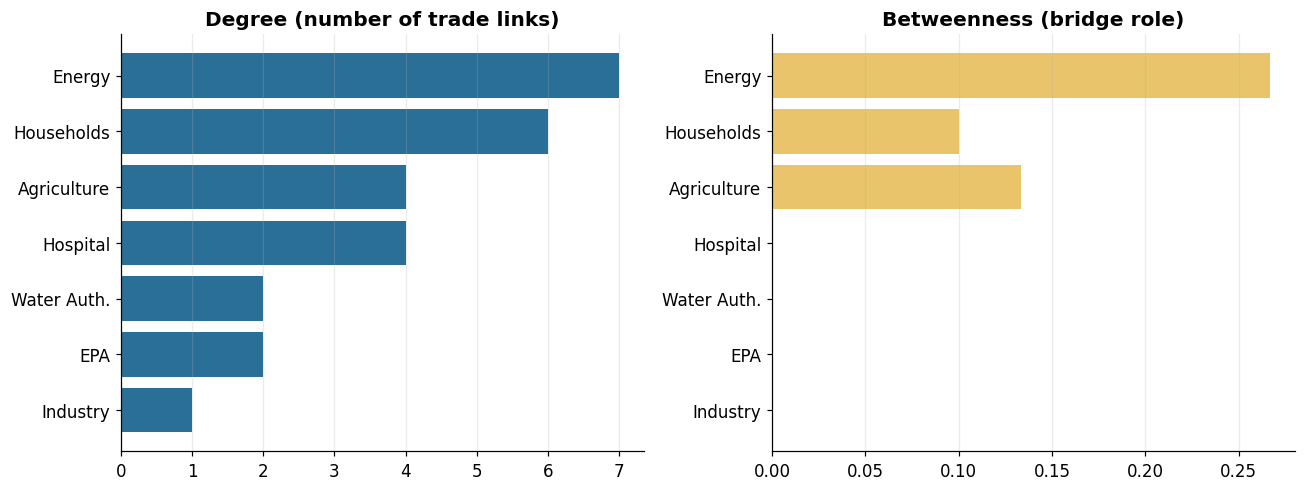

,degree,betweenness
Energy,7,0.267
Households,6,0.100
Agriculture,4,0.133
Hospital,4,0.000
EPA,2,0.000
Water Auth.,2,0.000
Industry,1,0.000


In [8]:
G = build_graph(trade_edges)
Gw = nx.DiGraph(); Gw.add_nodes_from(ALL_NODES)
for u,v,dd in G.edges(data=True): Gw.add_edge(u,v,weight=dd["count"])

deg  = dict(G.degree())
btw  = nx.betweenness_centrality(Gw, weight=None)
cen = (pd.DataFrame({"degree":deg, "betweenness":btw})
       .rename(index=LABELS).sort_values("degree", ascending=True))
cen = cen[cen["degree"]>0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].barh(cen.index, cen["degree"], color="#2a6f97")
axes[0].set_title("Degree (number of trade links)", weight="bold")
axes[1].barh(cen.index, cen["betweenness"], color="#e9c46a")
axes[1].set_title("Betweenness (bridge role)", weight="bold")
for a in axes: a.grid(axis="x", alpha=0.25)
plt.tight_layout(); plt.show()
cen.sort_values("degree", ascending=False).round(3)

## 4. 🔀 Trade network per scenario condition
Does the structure of cooperation change between `no_cascade`, `cascade`, `deeper_cascade`?
Node positions are fixed across panels for easy comparison.

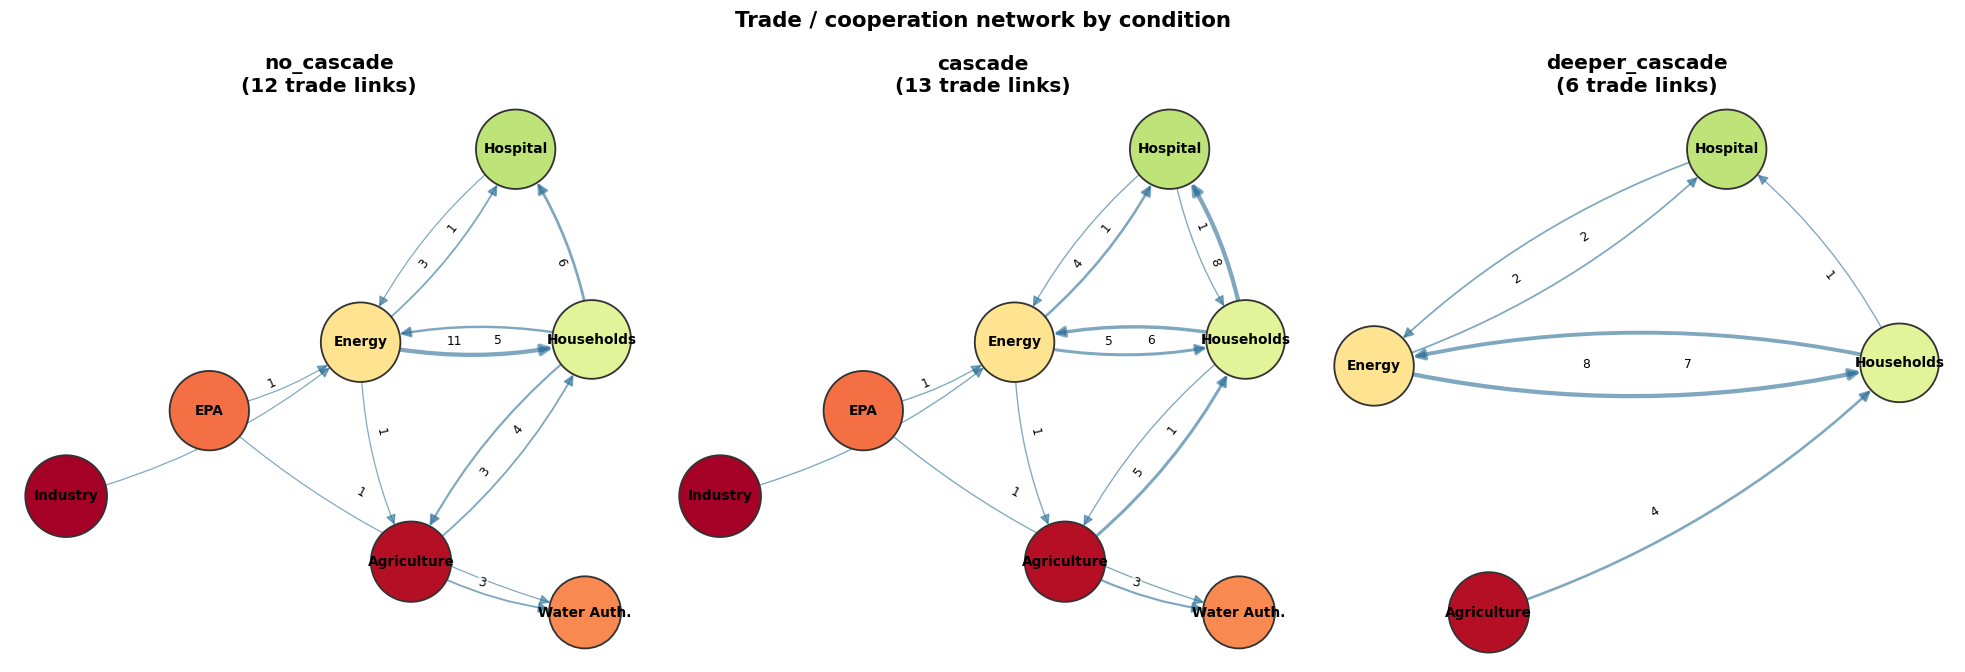

In [9]:
conds = ["no_cascade","cascade","deeper_cascade"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6.2))
for ax, c in zip(axes, conds):
    sub = decisions[decisions["condition"]==c]
    Gc = build_graph(edge_list(sub, "propose_trade"))
    n_edges = Gc.number_of_edges()
    if n_edges == 0:
        ax.text(0.5,0.5,"no trades", ha="center", va="center"); ax.axis("off")
        ax.set_title(f"{c}\n(0 trade links)", weight="bold"); continue
    draw_network(Gc, ax, f"{c}\n({n_edges} trade links)", edge_color="#2a6f97")
fig.suptitle("Trade / cooperation network by condition", fontsize=14, weight="bold")
plt.tight_layout(); plt.show()

## Takeaways

- The **trade network** (§1) shows the cooperation structure: who reaches out to whom to
  swap water — and the numbers reveal the busiest negotiating channels.
- The **cascade network** (§2) shows how one sector's shortfall propagates harm to others —
  the "blast radius" of a deficit.
- **Centrality** (§3) identifies the brokers/bridges that hold the trading system together.
- **Node color everywhere = VADER sentiment**, so you can instantly see whether the central,
  most-connected players are the negative (red) or positive (green) voices.
- **Per-condition panels** (§4) show whether escalating cascades densify or fracture cooperation.

> Want an interaction over time? Filter `decisions[decisions["day"]==k]` and rebuild the graph
> per day for an animation-style small-multiple.
